In [22]:
import numpy as np
import pandas as pd

In [23]:
# -----------------------------------------------------------------
# 0) دانلود دیتاست UCI Household Electricity
# -----------------------------------------------------------------

import os

if not os.path.exists("household_power_consumption.txt"):

    !wget -q "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip" -O household_power.zip
    !unzip -o household_power.zip

else:
    print("Dataset already exists. No need to download again.")

!ls -lh household_power_consumption.txt

Dataset already exists. No need to download again.
-rw-rw-r-- 1 root root 127M Oct 12  2012 household_power_consumption.txt


In [24]:
# -----------------------------------------------------------------
# 1) خواندن دیتاست خام
# -----------------------------------------------------------------

df_raw = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values=["?"]
)

print("شکل خام:", df_raw.shape)

print("\nستون‌ها:")
print(df_raw.columns.tolist())

print("\n5 ردیف اول:")
print(df_raw.head())

print("\nمقادیر گمشده:")
print(df_raw.isna().sum())

شکل خام: (2075259, 9)

ستون‌ها:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

5 ردیف اول:
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0         

In [25]:
# -----------------------------------------------------------------
# 2) پاک‌سازی و ساخت timestamp
# -----------------------------------------------------------------

# ساخت datetime
df_raw["datetime"] = pd.to_datetime(
    df_raw["Date"] + " " + df_raw["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

# حذف ستون‌های Date و Time و تبدیل datetime به index
df_raw = (
    df_raw
    .drop(columns=["Date", "Time"])
    .set_index("datetime")
    .sort_index()
)


# -----------------------------------------------------------------
# ستون‌های عددی
# -----------------------------------------------------------------

numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]


# تبدیل همه ستون‌ها به عدد
for c in numeric_cols:
    df_raw[c] = pd.to_numeric(
        df_raw[c],
        errors="coerce"
    )


# -----------------------------------------------------------------
# بررسی Missing Values قبل از interpolation
# -----------------------------------------------------------------

missing_before = df_raw[numeric_cols].isna().sum()

print("Missing values before interpolation:")
print(missing_before)


# -----------------------------------------------------------------
# Interpolation زمانی
# -----------------------------------------------------------------

df_raw[numeric_cols] = (
    df_raw[numeric_cols]
    .interpolate(
        method="time",
        limit=5
    )
)


# -----------------------------------------------------------------
# حذف Missingهای باقی‌مانده
# -----------------------------------------------------------------

df_raw = df_raw.dropna(
    subset=numeric_cols
)


# -----------------------------------------------------------------
# بررسی نهایی
# -----------------------------------------------------------------

missing_after = df_raw[numeric_cols].isna().sum()

print("\nMissing values after interpolation:")
print(missing_after)

print(
    "\nبعد از پاک‌سازی:",
    df_raw.shape
)

print(
    "بازه زمانی:",
    df_raw.index.min(),
    "تا",
    df_raw.index.max()
)

Missing values before interpolation:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing values after interpolation:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

بعد از پاک‌سازی: (2049436, 7)
بازه زمانی: 2006-12-16 17:24:00 تا 2010-11-26 21:02:00


In [26]:
# -----------------------------------------------------------------
# 3) Resample به ۱۰ دقیقه
# -----------------------------------------------------------------

df_10min = (
    df_raw[numeric_cols]
    .resample("10min")
    .mean()
    .dropna()
)

print(
    "بعد از resample به ۱۰ دقیقه:",
    df_10min.shape
)


# -----------------------------------------------------------------
# 4) ویژگی‌های زمانی چرخه‌ای
# -----------------------------------------------------------------

# ساعت
hour = df_10min.index.hour

# روز هفته: Monday=0 ... Sunday=6
dayofweek = df_10min.index.dayofweek


# ویژگی‌های چرخه‌ای ساعت
df_10min["hour_sin"] = np.sin(
    2 * np.pi * hour / 24
)

df_10min["hour_cos"] = np.cos(
    2 * np.pi * hour / 24
)


# ویژگی‌های چرخه‌ای روز هفته
df_10min["dow_sin"] = np.sin(
    2 * np.pi * dayofweek / 7
)

df_10min["dow_cos"] = np.cos(
    2 * np.pi * dayofweek / 7
)


# -----------------------------------------------------------------
# بررسی
# -----------------------------------------------------------------


print("\n5 ردیف اول:")
print(df_10min.head())

بعد از resample به ۱۰ دقیقه: (204959, 7)

5 ردیف اول:
                     Global_active_power  Global_reactive_power     Voltage  \
datetime                                                                      
2006-12-16 17:20:00             4.587333                 0.4840  234.366667   
2006-12-16 17:30:00             4.252200                 0.4608  234.208000   
2006-12-16 17:40:00             4.721600                 0.0308  234.845000   
2006-12-16 17:50:00             3.476200                 0.0424  235.045000   
2006-12-16 18:00:00             4.690400                 0.1526  234.975000   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:20:00             19.70             0.0        1.333333   
2006-12-16 17:30:00             18.28             0.0        1.100000   
2006-12-16 17:40:00             20.26             0.0        0.000000   
2006-12-16 17:50:00        

In [27]:
# -----------------------------------------------------------------
# 5) ساخت Target و Featureهای LSTM
# -----------------------------------------------------------------

# تبدیل Global_active_power به log scale
df_10min["target_log"] = np.log1p(
    df_10min["Global_active_power"]
)


# -----------------------------------------------------------------
# Featureهای مورد استفاده در LSTM
# -----------------------------------------------------------------

lstm_feature_cols = [
    "target_log",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]


# -----------------------------------------------------------------
# بررسی نهایی Featureها
# -----------------------------------------------------------------

print("LSTM features:")
for i, col in enumerate(lstm_feature_cols, start=1):
    print(f"{i:2d}. {col}")

print(
    "\nتعداد Featureها:",
    len(lstm_feature_cols)
)

print(
    "\nحجم دیتاست برای LSTM:",
    df_10min.shape
)

print("\nنمونه داده:")
print(
    df_10min[lstm_feature_cols].head()
)

LSTM features:
 1. target_log
 2. Global_reactive_power
 3. Voltage
 4. Global_intensity
 5. Sub_metering_1
 6. Sub_metering_2
 7. Sub_metering_3
 8. hour_sin
 9. hour_cos
10. dow_sin
11. dow_cos

تعداد Featureها: 11

حجم دیتاست برای LSTM: (204959, 12)

نمونه داده:
                     target_log  Global_reactive_power     Voltage  \
datetime                                                             
2006-12-16 17:20:00    1.720502                 0.4840  234.366667   
2006-12-16 17:30:00    1.658647                 0.4608  234.208000   
2006-12-16 17:40:00    1.744248                 0.0308  234.845000   
2006-12-16 17:50:00    1.498774                 0.0424  235.045000   
2006-12-16 18:00:00    1.738781                 0.1526  234.975000   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:20:00             19.70             0.0        1.333333   
2006-12-16 17:30:00     

In [28]:
# -----------------------------------------------------------------
# 6) بررسی نهایی داده برای LSTM
# -----------------------------------------------------------------

print("=" * 60)
print("LSTM DATASET SUMMARY")
print("=" * 60)

# Featureهای مورد استفاده
print("\nLSTM feature columns:")

for i, col in enumerate(lstm_feature_cols, start=1):
    print(f"{i:2d}. {col}")


# تعداد Featureها
print(
    "\nNumber of features:",
    len(lstm_feature_cols)
)


# حجم دیتاست
print(
    "Number of rows:",
    f"{len(df_10min):,}"
)


# شکل دیتاست
print(
    "DataFrame shape:",
    df_10min.shape
)


# بررسی Missing Values
print("\nMissing values in LSTM features:")

print(
    df_10min[lstm_feature_cols]
    .isna()
    .sum()
)


# چند ردیف اول
print("\nFirst 5 rows:")

print(
    df_10min[lstm_feature_cols].head()
)


# اطلاعات آماری target
print("\nTarget statistics:")

print(
    df_10min["target_log"].describe()
)

LSTM DATASET SUMMARY

LSTM feature columns:
 1. target_log
 2. Global_reactive_power
 3. Voltage
 4. Global_intensity
 5. Sub_metering_1
 6. Sub_metering_2
 7. Sub_metering_3
 8. hour_sin
 9. hour_cos
10. dow_sin
11. dow_cos

Number of features: 11
Number of rows: 204,959
DataFrame shape: (204959, 12)

Missing values in LSTM features:
target_log               0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
hour_sin                 0
hour_cos                 0
dow_sin                  0
dow_cos                  0
dtype: int64

First 5 rows:
                     target_log  Global_reactive_power     Voltage  \
datetime                                                             
2006-12-16 17:20:00    1.720502                 0.4840  234.366667   
2006-12-16 17:30:00    1.658647                 0.4608  234.208000   
2006-12-16 17:40:00    1.744248                 0.0308  23

In [29]:
print(df_10min.columns.tolist())

['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'target_log']


In [30]:
# -----------------------------------------------------------------
# 7) بررسی GPU
# -----------------------------------------------------------------

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

print("TensorFlow version:", tf.__version__)
print("GPU available:", gpus)

if gpus:
    print("✅ GPU is available.")
    print("GPU count:", len(gpus))
else:
    print("⚠️ GPU is NOT available. Training will run on CPU.")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU is available.
GPU count: 1


In [31]:
# -----------------------------------------------------------------
# 8) آماده‌سازی داده برای LSTM
# -----------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

df = df_10min.copy()

feature_cols = lstm_feature_cols

target_arr = df["target_log"].values
feature_arr = df[feature_cols].values


# -----------------------------------------------------------------
# تنظیمات Sequence
# -----------------------------------------------------------------

SEQ_LEN = 36          # 36 × 10 دقیقه = 6 ساعت
HORIZONS = [3, 4, 5, 6]


# -----------------------------------------------------------------
# Train / Test Split
# -----------------------------------------------------------------

split_idx = int(len(df) * 0.80)

print("Total rows :", len(df))
print("Train rows :", split_idx)
print("Test rows  :", len(df) - split_idx)


# -----------------------------------------------------------------
# Scaling
# فقط روی Train fit می‌کنیم
# -----------------------------------------------------------------

scaler_lstm = StandardScaler()

scaler_lstm.fit(
    feature_arr[:split_idx]
)

feature_arr_scaled = scaler_lstm.transform(
    feature_arr
)


# -----------------------------------------------------------------
# ساخت Sequenceهای Multi-Step
# -----------------------------------------------------------------

def make_multistep_sequences(
    feat_arr,
    target_arr,
    seq_len,
    horizons
):

    max_h = max(horizons)

    X_seq = []
    y_seq = []

    for i in range(
        len(feat_arr) - seq_len - max_h + 1
    ):

        # تاریخچه
        X_seq.append(
            feat_arr[i:i + seq_len]
        )

        # آخرین timestep در ورودی
        last_t = i + seq_len - 1

        # targetهای آینده
        y_seq.append(
            [
                target_arr[last_t + h]
                for h in horizons
            ]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )


# -----------------------------------------------------------------
# Train Sequence
# -----------------------------------------------------------------

X_train_seq, y_train_seq = make_multistep_sequences(
    feature_arr_scaled[:split_idx],
    target_arr[:split_idx],
    SEQ_LEN,
    HORIZONS
)


# -----------------------------------------------------------------
# Test Sequence
# -----------------------------------------------------------------

X_test_seq = []
y_test_seq = []

max_h = max(HORIZONS)

# آخرین timestep ورودی باید از split شروع شود
# تا اولین target مربوط به Test باشد.

for last_t in range(
    split_idx - 1,
    len(df) - max_h
):

    # تاریخچه 36 timestep
    X_test_seq.append(
        feature_arr_scaled[
            last_t - SEQ_LEN + 1 : last_t + 1
        ]
    )

    # targetهای آینده
    y_test_seq.append(
        [
            target_arr[last_t + h]
            for h in HORIZONS
        ]
    )

X_test_seq = np.array(X_test_seq)
y_test_seq = np.array(y_test_seq)

# -----------------------------------------------------------------
# بررسی شکل داده‌ها
# -----------------------------------------------------------------

print("\nSequence shapes:")

print(
    "X_train:",
    X_train_seq.shape
)

print(
    "y_train:",
    y_train_seq.shape
)

print(
    "X_test :",
    X_test_seq.shape
)

print(
    "y_test :",
    y_test_seq.shape
)


# -----------------------------------------------------------------
# بررسی مورد انتظار
# -----------------------------------------------------------------

print("\nExpected input shape:")
print(
    "(samples, 36, 11)"
)

print("\nExpected output shape:")
print(
    "(samples, 4)"
)

Total rows : 204959
Train rows : 163967
Test rows  : 40992

Sequence shapes:
X_train: (163926, 36, 11)
y_train: (163926, 4)
X_test : (40987, 36, 11)
y_test : (40987, 4)

Expected input shape:
(samples, 36, 11)

Expected output shape:
(samples, 4)


In [32]:
print("\nTest sequence validation:")

print("First test input ends at:",
      split_idx - 1)

print("First test targets:")
print([
    split_idx - 1 + h
    for h in HORIZONS
])

print("Expected: all target indices >= split_idx")


Test sequence validation:
First test input ends at: 163966
First test targets:
[163969, 163970, 163971, 163972]
Expected: all target indices >= split_idx


In [33]:
# -----------------------------------------------------------------
# 9) ساخت و آموزش مدل LSTM Multi-Step
# -----------------------------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# -----------------------------------------------------------------
# ساخت مدل
# -----------------------------------------------------------------

model_lstm_multi = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(SEQ_LEN, X_train_seq.shape[2])
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    # چهار خروجی:
    # t+3, t+4, t+5, t+6
    Dense(len(HORIZONS))
])


# -----------------------------------------------------------------
# Compile
# -----------------------------------------------------------------

model_lstm_multi.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)


# -----------------------------------------------------------------
# نمایش معماری مدل
# -----------------------------------------------------------------

model_lstm_multi.summary()


# -----------------------------------------------------------------
# Early Stopping
# -----------------------------------------------------------------

es_multi = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


# -----------------------------------------------------------------
# Time-Series Validation Split
# -----------------------------------------------------------------

val_size = int(len(X_train_seq) * 0.15)

X_train_final = X_train_seq[:-val_size]
y_train_final = y_train_seq[:-val_size]

X_val = X_train_seq[-val_size:]
y_val = y_train_seq[-val_size:]


print("\nTraining samples  :", len(X_train_final))
print("Validation samples:", len(X_val))


# -----------------------------------------------------------------
# Training
# -----------------------------------------------------------------

history_multi = model_lstm_multi.fit(

    X_train_final,
    y_train_final,

    validation_data=(X_val, y_val),

    epochs=100,

    batch_size=256,

    callbacks=[es_multi],

    # بسیار مهم برای Time Series
    shuffle=False,

    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 36, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 36, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,468 (126.83 KB)

 Trainable params: 32,468 (126.83 KB)

 Non-trainable params: 0 (0.00 B)


Training samples  : 139338
Validation samples: 24588
Epoch 1/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.1329 - mae: 0.2672 - val_loss: 0.1502 - val_mae: 0.2828
Epoch 2/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0915 - mae: 0.2241 - val_loss: 0.1322 - val_mae: 0.2634
Epoch 3/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0861 - mae: 0.2152 - val_loss: 0.1236 - val_mae: 0.2538
Epoch 4/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0831 - mae: 0.2104 - val_loss: 0.1192 - val_mae: 0.2490
Epoch 5/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0812 - mae: 0.2073 - val_loss: 0.1157 - val_mae: 0.2458
Epoch 6/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0797 - mae: 0.2044 - val_loss: 0.1111 - val_mae: 0.2409
Epoch 7/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0784 - mae: 0.2022 - val_loss: 0.1091 - val_mae: 0.2390
Epoch 8/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0773 - mae: 0.2006 - val_loss: 0.1085 - val

In [34]:
# -----------------------------------------------------------------
# 10) Prediction و Evaluation مدل LSTM
# -----------------------------------------------------------------

from sklearn.metrics import r2_score, mean_absolute_error

# پیش‌بینی روی Test
y_pred_multi = model_lstm_multi.predict(
    X_test_seq,
    verbose=1
)


# -----------------------------------------------------------------
# محاسبه نتایج
# -----------------------------------------------------------------

lstm_results = []

print("\n" + "=" * 65)
print("LSTM Multi-Step Forecasting Results")
print("=" * 65)

for idx, h in enumerate(HORIZONS):

    # مقدار واقعی و پیش‌بینی‌شده در log scale
    yt = y_test_seq[:, idx]
    yp = y_pred_multi[:, idx]

    # R² در log scale
    r2 = r2_score(
        yt,
        yp
    )

    # برگرداندن به مقیاس اصلی
    yt_real = np.expm1(yt)
    yp_real = np.expm1(yp)

    # MAE در مقیاس اصلی
    mae_real = mean_absolute_error(
        yt_real,
        yp_real
    )

    # ذخیره نتیجه
    lstm_results.append({
        "Horizon": f"t+{h}",
        "Minutes": h * 10,
        "R2": r2,
        "MAE": mae_real
    })

    print(
        f"t+{h} (~{h*10} min) | "
        f"R²={r2:.4f} | "
        f"MAE={mae_real:.4f}"
    )


# -----------------------------------------------------------------
# تبدیل نتایج به DataFrame
# -----------------------------------------------------------------

lstm_results_df = pd.DataFrame(
    lstm_results
)

print("\nResults table:")
print(
    lstm_results_df.round(4).to_string(
        index=False
    )
)

1281/1281 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

LSTM Multi-Step Forecasting Results
t+3 (~30 min) | R²=0.4698 | MAE=0.4305
t+4 (~40 min) | R²=0.4013 | MAE=0.4601
t+5 (~50 min) | R²=0.3417 | MAE=0.4830
t+6 (~60 min) | R²=0.3070 | MAE=0.4980

Results table:
Horizon  Minutes     R2    MAE
    t+3       30 0.4698 0.4305
    t+4       40 0.4013 0.4601
    t+5       50 0.3417 0.4830
    t+6       60 0.3070 0.4980


In [35]:
# -----------------------------------------------------------------
# 11) Persistence Baseline
# -----------------------------------------------------------------

from sklearn.metrics import r2_score, mean_absolute_error

persistence_results = []

print("\n" + "=" * 65)
print("Persistence Baseline Results")
print("=" * 65)

# آخرین مقدار مشاهده‌شده در هر sequence
# X_test_seq شامل featureهای scale شده است.
# target_log اولین feature است، بنابراین باید آن را
# به مقیاس اصلی برگردانیم.

target_feature_idx = feature_cols.index("target_log")

# مقدار آخرین target مشاهده‌شده در هر sequence
last_target_scaled = X_test_seq[:, -1, target_feature_idx]

# برگرداندن target_log از StandardScaler
target_mean = scaler_lstm.mean_[target_feature_idx]
target_scale = scaler_lstm.scale_[target_feature_idx]

last_target_log = (
    last_target_scaled * target_scale
    + target_mean
)


# -----------------------------------------------------------------
# ارزیابی برای هر Horizon
# -----------------------------------------------------------------

for idx, h in enumerate(HORIZONS):

    yt_log = y_test_seq[:, idx]

    # Persistence:
    # پیش‌بینی می‌کنیم مصرف آینده برابر آخرین مصرف مشاهده‌شده باشد
    yp_log = last_target_log

    # R² روی log scale
    r2_pers = r2_score(
        yt_log,
        yp_log
    )

    # تبدیل به مقیاس واقعی
    yt_real = np.expm1(yt_log)
    yp_real = np.expm1(yp_log)

    mae_pers = mean_absolute_error(
        yt_real,
        yp_real
    )

    persistence_results.append({
        "Horizon": f"t+{h}",
        "Minutes": h * 10,
        "R2": r2_pers,
        "MAE": mae_pers
    })

    print(
        f"t+{h} (~{h*10} min) | "
        f"R²={r2_pers:.4f} | "
        f"MAE={mae_pers:.4f}"
    )


# -----------------------------------------------------------------
# جدول نتایج
# -----------------------------------------------------------------

persistence_results_df = pd.DataFrame(
    persistence_results
)

print("\nPersistence results:")
print(
    persistence_results_df.round(4).to_string(
        index=False
    )
)


Persistence Baseline Results
t+3 (~30 min) | R²=0.3952 | MAE=0.4273
t+4 (~40 min) | R²=0.2624 | MAE=0.4786
t+5 (~50 min) | R²=0.1598 | MAE=0.5158
t+6 (~60 min) | R²=0.0794 | MAE=0.5468

Persistence results:
Horizon  Minutes     R2    MAE
    t+3       30 0.3952 0.4273
    t+4       40 0.2624 0.4786
    t+5       50 0.1598 0.5158
    t+6       60 0.0794 0.5468


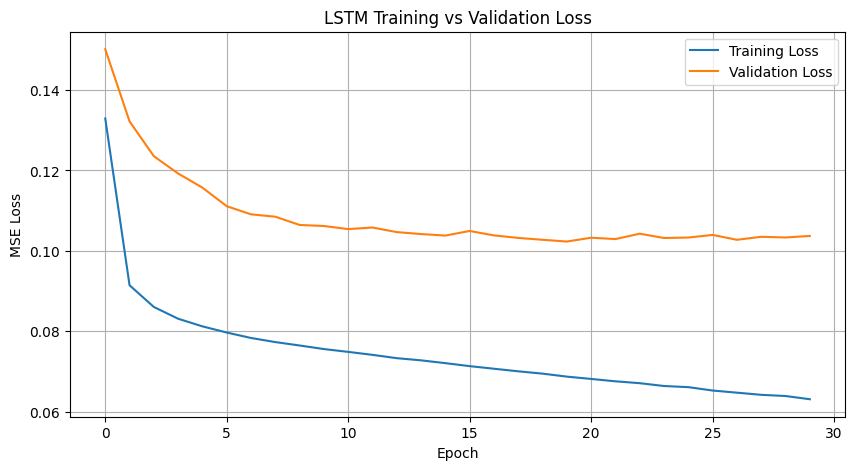

In [36]:
# -----------------------------------------------------------------
# 12) LSTM Training History
# -----------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history_multi.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_multi.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "LSTM Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

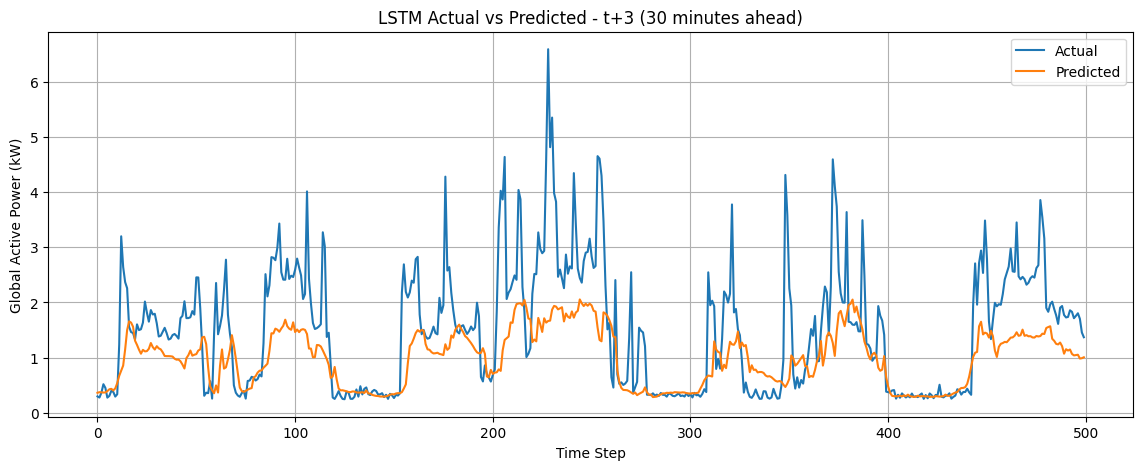

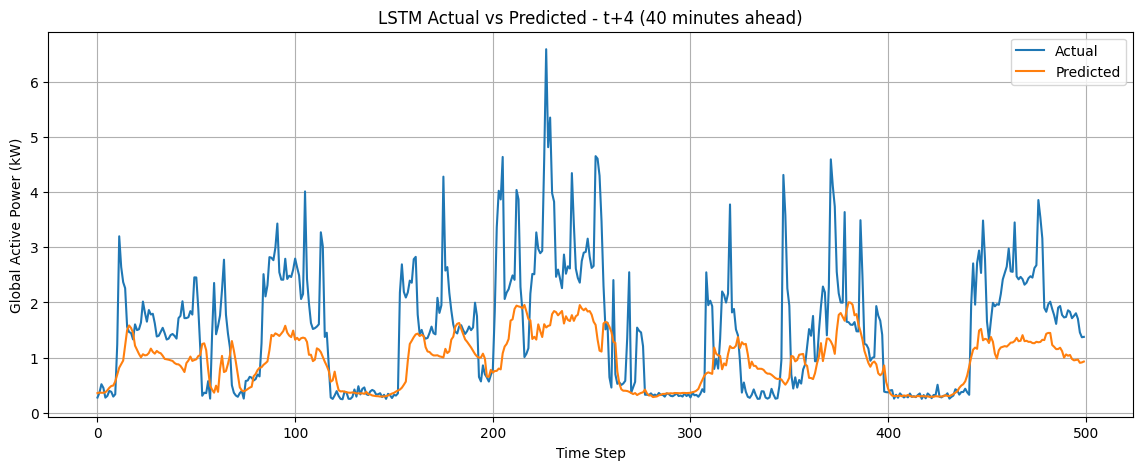

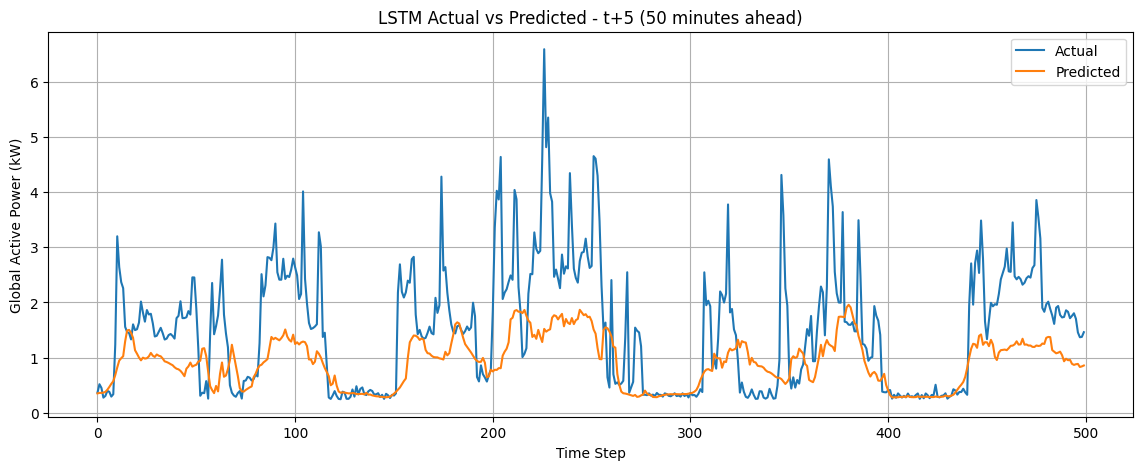

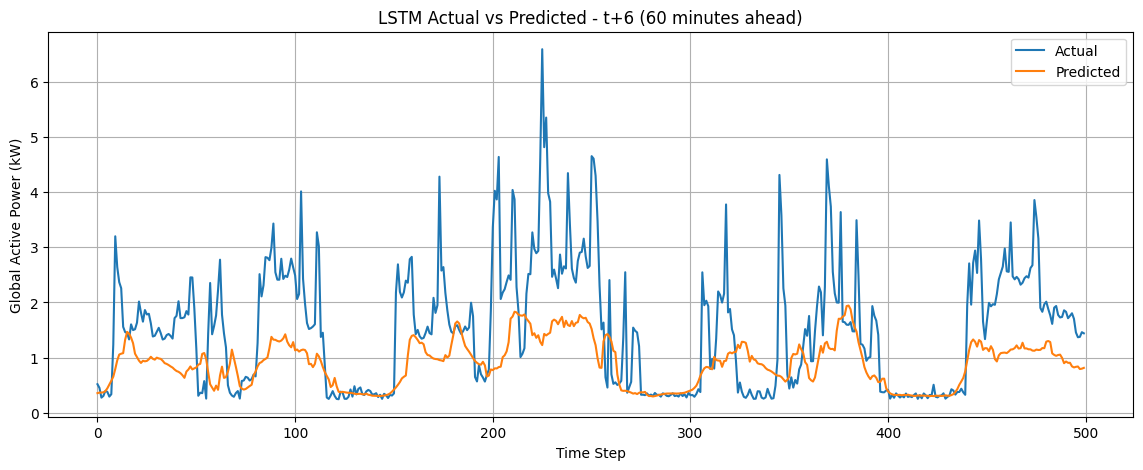

In [37]:
# -----------------------------------------------------------------
# 13) Actual vs Predicted
# -----------------------------------------------------------------

import matplotlib.pyplot as plt

for idx, h in enumerate(HORIZONS):

    yt_real = np.expm1(
        y_test_seq[:, idx]
    )

    yp_real = np.expm1(
        y_pred_multi[:, idx]
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        yt_real[:500],
        label="Actual"
    )

    plt.plot(
        yp_real[:500],
        label="Predicted"
    )

    plt.xlabel("Time Step")
    plt.ylabel("Global Active Power (kW)")

    plt.title(
        f"LSTM Actual vs Predicted - t+{h} "
        f"({h * 10} minutes ahead)"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

In [38]:
# -----------------------------------------------------------------
# 14) LSTM vs Persistence Comparison
# -----------------------------------------------------------------

comparison_df = lstm_results_df[
    ["Horizon", "Minutes", "R2", "MAE"]
].copy()

comparison_df = comparison_df.rename(
    columns={
        "R2": "LSTM_R2",
        "MAE": "LSTM_MAE"
    }
)

comparison_df["Persistence_R2"] = (
    persistence_results_df["R2"].values
)

comparison_df["Persistence_MAE"] = (
    persistence_results_df["MAE"].values
)

print("=" * 80)
print("LSTM vs Persistence Comparison")
print("=" * 80)

print(
    comparison_df.round(4).to_string(index=False)
)

LSTM vs Persistence Comparison
Horizon  Minutes  LSTM_R2  LSTM_MAE  Persistence_R2  Persistence_MAE
    t+3       30   0.4698    0.4305          0.3952           0.4273
    t+4       40   0.4013    0.4601          0.2624           0.4786
    t+5       50   0.3417    0.4830          0.1598           0.5158
    t+6       60   0.3070    0.4980          0.0794           0.5468


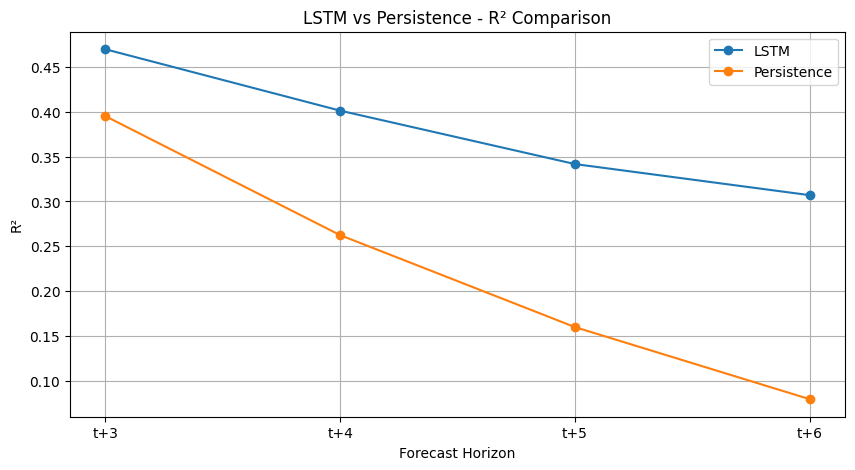

In [39]:
# -----------------------------------------------------------------
# 15) R² Comparison
# -----------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    comparison_df["Horizon"],
    comparison_df["LSTM_R2"],
    marker="o",
    label="LSTM"
)

plt.plot(
    comparison_df["Horizon"],
    comparison_df["Persistence_R2"],
    marker="o",
    label="Persistence"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("R²")

plt.title(
    "LSTM vs Persistence - R² Comparison"
)

plt.legend()
plt.grid(True)

plt.show()

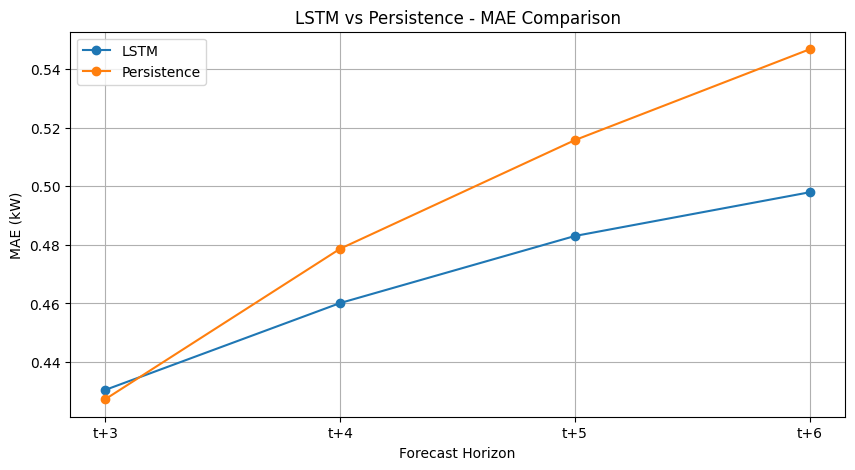

In [40]:
# -----------------------------------------------------------------
# 16) MAE Comparison
# -----------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    comparison_df["Horizon"],
    comparison_df["LSTM_MAE"],
    marker="o",
    label="LSTM"
)

plt.plot(
    comparison_df["Horizon"],
    comparison_df["Persistence_MAE"],
    marker="o",
    label="Persistence"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("MAE (kW)")

plt.title(
    "LSTM vs Persistence - MAE Comparison"
)

plt.legend()
plt.grid(True)

plt.show()

In [41]:
# -----------------------------------------------------------------
# 17) SimpleRNN Multi-Step Forecasting
# -----------------------------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# -----------------------------------------------------------------
# ساخت مدل SimpleRNN
# -----------------------------------------------------------------

model_rnn_multi = Sequential([

    SimpleRNN(
        64,
        return_sequences=True,
        input_shape=(SEQ_LEN, X_train_seq.shape[2])
    ),

    Dropout(0.2),

    SimpleRNN(32),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    # چهار خروجی:
    # t+3, t+4, t+5, t+6
    Dense(len(HORIZONS))
])


# -----------------------------------------------------------------
# Compile
# -----------------------------------------------------------------

model_rnn_multi.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)


# -----------------------------------------------------------------
# Model Summary
# -----------------------------------------------------------------

model_rnn_multi.summary()


# -----------------------------------------------------------------
# Early Stopping
# -----------------------------------------------------------------

es_rnn = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


# -----------------------------------------------------------------
# Training
# همان Training / Validation که برای LSTM داشتیم
# -----------------------------------------------------------------

history_rnn = model_rnn_multi.fit(

    X_train_final,
    y_train_final,

    validation_data=(X_val, y_val),

    epochs=100,

    batch_size=256,

    callbacks=[es_rnn],

    shuffle=False,

    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 36, 64)         │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 36, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,564 (33.45 KB)

 Trainable params: 8,564 (33.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.1432 - mae: 0.2789 - val_loss: 0.1476 - val_mae: 0.2815
Epoch 2/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0934 - mae: 0.2261 - val_loss: 0.1371 - val_mae: 0.2660
Epoch 3/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0893 - mae: 0.2193 - val_loss: 0.1334 - val_mae: 0.2609
Epoch 4/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0869 - mae: 0.2153 - val_loss: 0.1294 - val_mae: 0.2569
Epoch 5/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0855 - mae: 0.2130 - val_loss: 0.1252 - val_mae: 0.2527
Epoch 6/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0848 - mae: 0.2119 - val_loss: 0.1248 - val_mae: 0.2519
Epoch 7/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0838 - mae: 0.2106 - val_loss: 0.1223 - val_mae: 0.2491
Epoch 8/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0833 - mae: 0.2099 - val_loss: 0.1207 - val_mae: 0.2479
Epoch 9/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 5s 

In [43]:
# -----------------------------------------------------------------
# 18) SimpleRNN Evaluation
# -----------------------------------------------------------------

y_pred_rnn = model_rnn_multi.predict(
    X_test_seq,
    verbose=1
)

rnn_results = []

print("\n" + "=" * 65)
print("SimpleRNN Multi-Step Forecasting Results")
print("=" * 65)

for idx, h in enumerate(HORIZONS):

    yt_log = y_test_seq[:, idx]
    yp_log = y_pred_rnn[:, idx]

    r2 = r2_score(
        yt_log,
        yp_log
    )

    yt_real = np.expm1(yt_log)
    yp_real = np.expm1(yp_log)

    mae = mean_absolute_error(
        yt_real,
        yp_real
    )

    rnn_results.append({
        "Horizon": f"t+{h}",
        "Minutes": h * 10,
        "R2": r2,
        "MAE": mae
    })

    print(
        f"t+{h} (~{h*10} min) | "
        f"R²={r2:.4f} | "
        f"MAE={mae:.4f}"
    )

rnn_results_df = pd.DataFrame(rnn_results)

print("\nSimpleRNN results:")
print(
    rnn_results_df.round(4).to_string(index=False)
)

1281/1281 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step

SimpleRNN Multi-Step Forecasting Results
t+3 (~30 min) | R²=0.5205 | MAE=0.3981
t+4 (~40 min) | R²=0.4602 | MAE=0.4264
t+5 (~50 min) | R²=0.4165 | MAE=0.4477
t+6 (~60 min) | R²=0.3825 | MAE=0.4638

SimpleRNN results:
Horizon  Minutes     R2    MAE
    t+3       30 0.5205 0.3981
    t+4       40 0.4602 0.4264
    t+5       50 0.4165 0.4477
    t+6       60 0.3825 0.4638


In [44]:
# -----------------------------------------------------------------
# 19) SimpleRNN vs LSTM
# -----------------------------------------------------------------

rnn_lstm_comparison = pd.DataFrame({

    "Horizon": lstm_results_df["Horizon"],

    "Minutes": lstm_results_df["Minutes"],

    "LSTM_R2": lstm_results_df["R2"],

    "SimpleRNN_R2": rnn_results_df["R2"],

    "LSTM_MAE": lstm_results_df["MAE"],

    "SimpleRNN_MAE": rnn_results_df["MAE"]
})


print("=" * 80)
print("SimpleRNN vs LSTM Comparison")
print("=" * 80)

print(
    rnn_lstm_comparison.round(4).to_string(index=False)
)

SimpleRNN vs LSTM Comparison
Horizon  Minutes  LSTM_R2  SimpleRNN_R2  LSTM_MAE  SimpleRNN_MAE
    t+3       30   0.4698        0.5205    0.4305         0.3981
    t+4       40   0.4013        0.4602    0.4601         0.4264
    t+5       50   0.3417        0.4165    0.4830         0.4477
    t+6       60   0.3070        0.3825    0.4980         0.4638


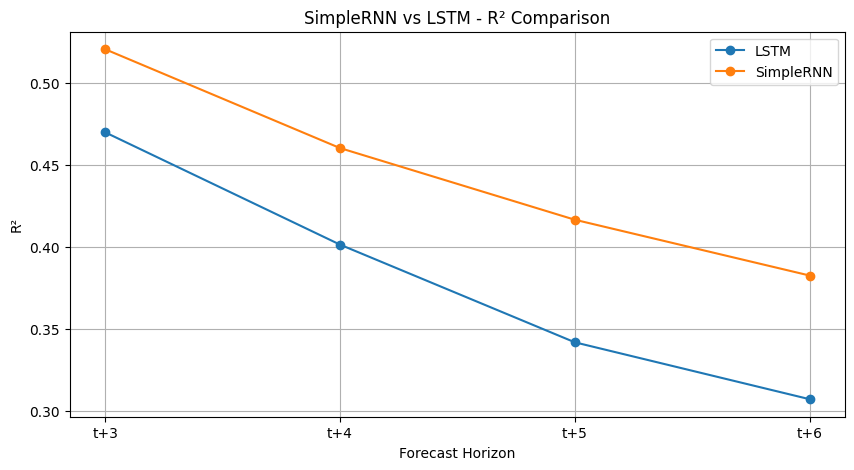

In [45]:
# -----------------------------------------------------------------
# 20) R²: SimpleRNN vs LSTM
# -----------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    rnn_lstm_comparison["Horizon"],
    rnn_lstm_comparison["LSTM_R2"],
    marker="o",
    label="LSTM"
)

plt.plot(
    rnn_lstm_comparison["Horizon"],
    rnn_lstm_comparison["SimpleRNN_R2"],
    marker="o",
    label="SimpleRNN"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("R²")

plt.title(
    "SimpleRNN vs LSTM - R² Comparison"
)

plt.legend()
plt.grid(True)

plt.show()